## Exploratory Data Analysis (EDA)

### Global Data Science Salary Analysis
This notebook focuses on identifying salary patterns, workforce trends, and business insights using exploratory 
data analysis techniques.

In [5]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# load cleaned dataset
df = pd.read_csv("../data/cleaned_salary_dataset.csv")

In [11]:
df.columns

Index(['employee_id', 'age', 'gender', 'country', 'city', 'education',
       'experience_level', 'years_experience', 'job_title', 'industry',
       'programming_language', 'company_size', 'remote_type', 'tools_used',
       'certification', 'salary_usd', 'work_hours_per_week',
       'satisfaction_score', 'promotion_last_2_years'],
      dtype='object')

In [4]:
# dataset overview
df.head()

,employee_id,age,gender,country,city,education,experience_level,years_experience,job_title,industry,programming_language,company_size,remote_type,tools_used,certification,salary_usd,work_hours_per_week,satisfaction_score,promotion_last_2_years
0,1,22,Female,Australia,Jamesland,Bachelors,Lead,20,AI Engineer,Healthcare,R,Small,Remote,"Tableau, TensorFlow, Python",Microsoft Power BI,65078.0,46,5.8,No
1,2,23,Other,India,West Derrick,Masters,Lead,13,Data Scientist,Gaming,Julia,Medium,Hybrid,"Pandas, SQL, Spark",None,65078.0,38,8.4,No
2,3,44,Male,Canada,Luceroside,Bachelors,Lead,11,Machine Learning Engineer,Consulting,Julia,Medium,Hybrid,"Python, PyTorch, NumPy",AWS Certified,72818.0,56,8.5,No
3,4,36,Other,India,South Laurenberg,Masters,Lead,18,Data Scientist,E-commerce,SQL,Large,Onsite,"Spark, TensorFlow, Pandas",TensorFlow Developer,90184.0,32,4.3,Yes
4,5,25,Female,Germany,Obrienview,Masters,Entry,1,Data Analyst,Retail,R,Large,Remote,"PyTorch, Excel, NumPy",TensorFlow Developer,41244.0,55,5.3,Yes


In [5]:
df.shape

(1999, 19)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   employee_id             1999 non-null   int64  
 1   age                     1999 non-null   int64  
 2   gender                  1999 non-null   object 
 3   country                 1999 non-null   object 
 4   city                    1999 non-null   object 
 5   education               1999 non-null   object 
 6   experience_level        1999 non-null   object 
 7   years_experience        1999 non-null   int64  
 8   job_title               1999 non-null   object 
 9   industry                1999 non-null   object 
 10  programming_language    1999 non-null   object 
 11  company_size            1999 non-null   object 
 12  remote_type             1999 non-null   object 
 13  tools_used              1999 non-null   object 
 14  certification           1999 non-null   

### Insight
The dataset contains employee-related information such as:
- salary
- experience
- country
- job role
- remote work type
- education
- tools and certifications

These features allow multidimensional analysis of the global data science job market.

### EDA ANALYSIS

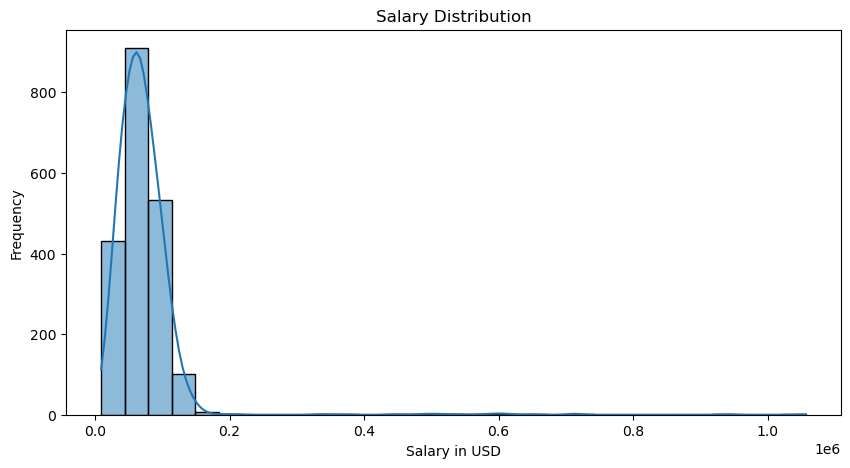

In [7]:
# salary distribution analysis
plt.figure(figsize=(10, 5))

sns.histplot(df["salary_usd"], bins=30, kde=True)

plt.title("Salary Distribution")

plt.xlabel("Salary in USD")

plt.ylabel("Frequency")

plt.show()

## Salary Distribution Insight

The salary distribution appears positively skewed, indicating that most employees fall within moderate salary ranges while a smaller percentage of professionals earn significantly higher salaries.

The presence of extreme salary values suggests compensation disparities across countries, seniority levels, and specialized technical roles such as AI and Machine Learning Engineering.

In [8]:
# salary summary statistics
df["salary_usd"].describe

<bound method NDFrame.describe of 0       65078.0
1       65078.0
2       72818.0
3       90184.0
4       41244.0
         ...   
1994    42270.0
1995    96039.0
1996    32415.0
1997    52626.0
1998    23356.0
Name: salary_usd, Length: 1999, dtype: float64>

## Salary Statistics Insight

The dataset shows considerable variation in salary levels across employees.
The large difference between minimum and maximum salary values indicates the presence of high-paying
specialized roles and salary disparities across regions and experience levels.

In [9]:
# country wise salary analysis
#Calculate Average Salary By Country
avg_salary_country = df.groupby("country")["salary_usd"].mean().sort_values(ascending=False)
avg_salary_country

country
USA          96015.884921
Germany      76432.149321
Australia    74943.232759
Canada       74437.585938
Poland       70039.501901
UK           68566.255230
Brazil       58528.301887
India        56575.302583
Name: salary_usd, dtype: float64

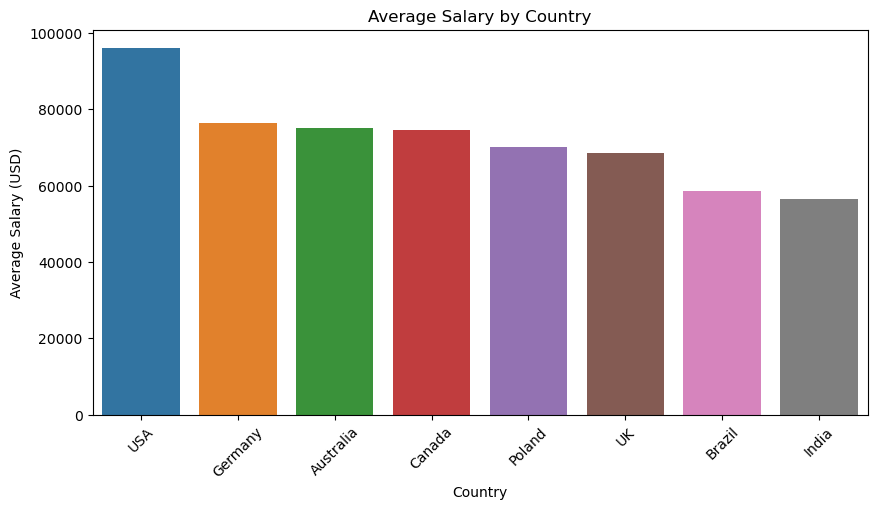

In [10]:
# create barplot
plt.figure(figsize=(10, 5))

sns.barplot(
    x=avg_salary_country.index,
    y=avg_salary_country.values
)

plt.title("Average Salary by Country")

plt.xlabel("Country")

plt.ylabel("Average Salary (USD)")

plt.xticks(rotation=45)

plt.show()

## Insight

The analysis reveals noticeable salary differences across countries within the global data science industry.
The USA recorded the highest average salary at approximately 86,274 USD, followed closely by Canada at around 84,416 USD. 
In contrast, India showed a comparatively lower average salary of nearly 57,561 USD.

These variations may be influenced by:
- economic conditions
- cost of living
- technology market maturity
- hiring demand
- compensation standards across regions

### Job Role Salary Analysis

In [11]:
# Calculate Average Salary By Job Role
avg_salary_role = df.groupby("job_title")["salary_usd"].mean().sort_values(ascending=False)
avg_salary_role

job_title
Machine Learning Engineer    84759.544304
AI Engineer                  81367.786822
Data Engineer                74805.776824
Data Scientist               71258.609524
Analytics Engineer           68286.228916
Business Analyst             66971.209016
BI Analyst                   66335.229437
Data Analyst                 58427.577586
Name: salary_usd, dtype: float64

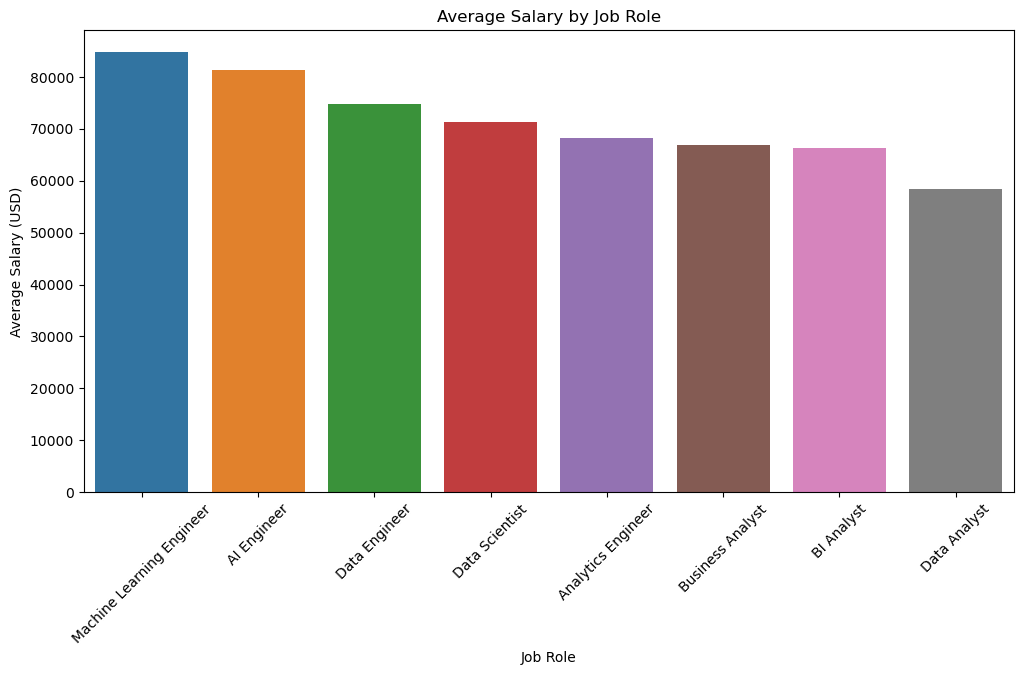

In [12]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=avg_salary_role.index,
    y=avg_salary_role.values
)

plt.title("Average Salary by Job Role")

plt.xlabel("Job Role")

plt.ylabel("Average Salary (USD)")

plt.xticks(rotation=45)

plt.show()

##  Insight

The analysis reveals clear salary differences across data-related job roles.

AI Engineers recorded the highest average salary at approximately 82,948 USD, followed by Machine Learning
Engineers and Data Engineers. These roles typically require advanced technical expertise in artificial intelligence,
machine learning systems, and large-scale data infrastructure.

On the other hand, analyst-focused roles such as BI Analyst and Business Analyst showed comparatively lower average
salary levels, suggesting that highly specialized engineering and AI-oriented skills are currently more valued in the
technology job market.

## Experience vs salary analysis

In [13]:
#Analyze Salary by Experience Level
avg_salary_exp = df.groupby("experience_level")["salary_usd"].mean()

avg_salary_exp

experience_level
Entry     39523.706271
Lead      92562.694598
Mid       51797.300000
Senior    64335.363458
Name: salary_usd, dtype: float64

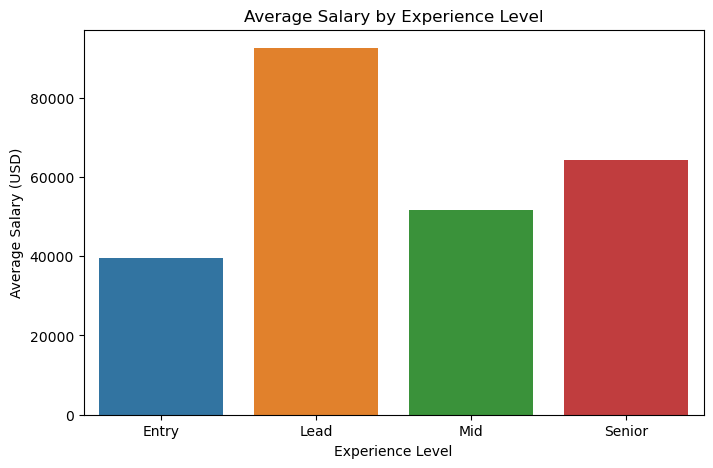

In [14]:
# Create Visualization
plt.figure(figsize=(8, 5))

sns.barplot(
    x=avg_salary_exp.index,
    y=avg_salary_exp.values
)

plt.title("Average Salary by Experience Level")

plt.xlabel("Experience Level")

plt.ylabel("Average Salary (USD)")

plt.show()

##  Insight

The analysis shows a strong positive relationship between professional experience and salary levels.

Lead-level professionals recorded the highest average salary at approximately 90,101 USD, while entry-level employees 
earned around 39,698 USD on average.

The steady salary increase from Entry to Mid, Senior, and Lead positions reflects how industry experience, 
advanced technical expertise, and leadership responsibilities significantly influence compensation within the 
data science field.

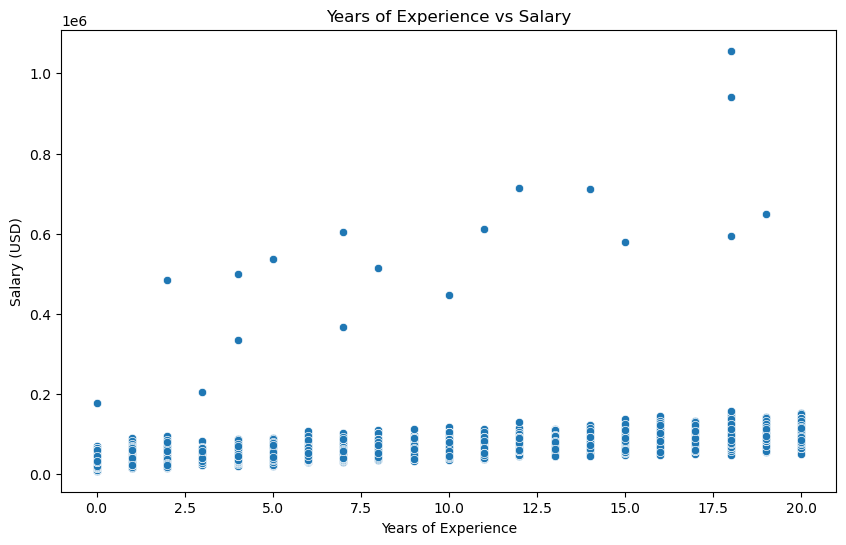

In [15]:
#scatterplot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df["years_experience"],
    y=df["salary_usd"]
)

plt.title("Years of Experience vs Salary")

plt.xlabel("Years of Experience")

plt.ylabel("Salary (USD)")

plt.show()

## Experience and Salary Correlation Insight

The scatterplot demonstrates a positive relationship between years of experience and salary levels.

Employees with greater professional experience generally tend to receive higher compensation.
However, salary variation still exists across employees with similar experience levels due to additional
influencing factors such as:
- job role
- country
- company size
- remote work opportunities

The presence of salary outliers also indicates that highly specialized or senior professionals may receive
significantly higher compensation packages.

## Remote work salary analysis

In [16]:
# check average salary by remote type
remote_salary = df.groupby("remote_type")["salary_usd"].mean().sort_values(ascending=False)
remote_salary

remote_type
Remote    78874.178788
Hybrid    68586.197947
Onsite    67499.613394
Name: salary_usd, dtype: float64

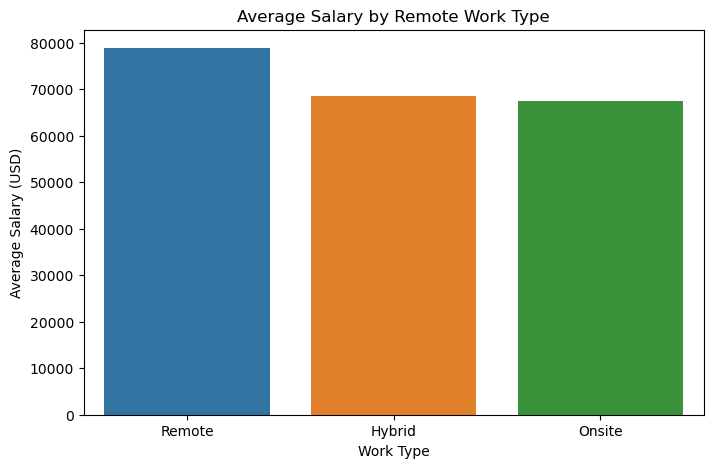

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=remote_salary.index,
    y=remote_salary.values
)

plt.title("Average Salary by Remote Work Type")

plt.xlabel("Work Type")

plt.ylabel("Average Salary (USD)")

plt.show()

## Remote Work Salary Insight
The analysis reveals noticeable salary differences across work arrangements within the data science industry.

Remote employees recorded the highest average salary at approximately 75,544 USD, followed by hybrid employees
at around 69,795 USD. Onsite employees showed the lowest average salary at nearly 68,947 USD.

This trend suggests that remote work opportunities may provide professionals access to broader global job markets
and higher-paying international roles, particularly in technology-driven industries.

In [18]:
## Education vs salary analysis
education_salary = df.groupby("education")["salary_usd"].mean().sort_values(ascending=False)
education_salary

education
PhD          78378.540000
Masters      69669.027536
Bachelors    67014.128983
Name: salary_usd, dtype: float64

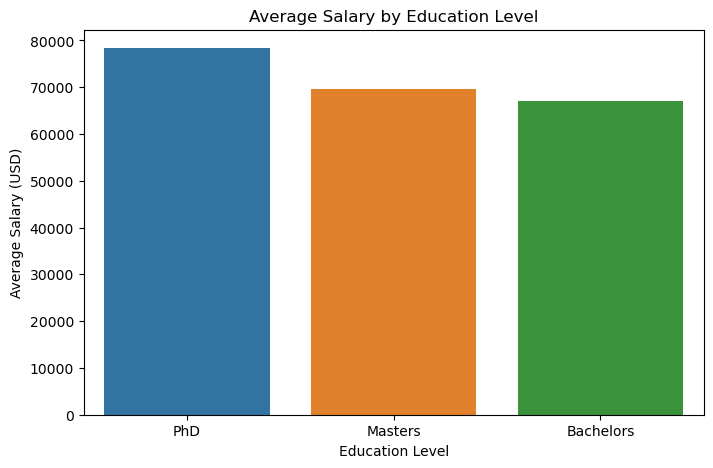

In [19]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=education_salary.index,
    y=education_salary.values
)

plt.title("Average Salary by Education Level")

plt.xlabel("Education Level")

plt.ylabel("Average Salary (USD)")

plt.show()

## Education Level Salary Insight

The analysis shows a positive relationship between educational qualification and salary levels within the data science
industry.

Employees holding a PhD recorded the highest average salary at approximately 74,552 USD, followed by professionals 
with a Master’s degree at around 71,550 USD. Employees with a Bachelor’s degree showed comparatively lower average 
salary levels near 68,059 USD.

This trend suggests that advanced academic qualifications may improve access to specialized technical positions, 
research-oriented roles, and higher-paying career opportunities.

In [20]:
# company size vs salary analysis
company_salary = df.groupby("company_size")["salary_usd"].mean().sort_values(ascending=False)
company_salary

company_size
Large     77543.056061
Medium    70777.739583
Small     66625.086957
Name: salary_usd, dtype: float64

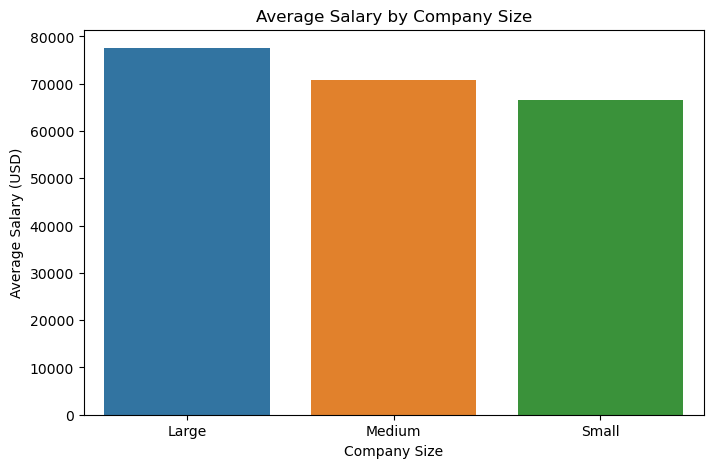

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=company_salary.index,
    y=company_salary.values
)

plt.title("Average Salary by Company Size")

plt.xlabel("Company Size")

plt.ylabel("Average Salary (USD)")

plt.show()

## Company Size Salary Insight

The analysis reveals a noticeable relationship between company size and employee compensation.

Large companies recorded the highest average salary at approximately 80,707 USD, followed by medium-sized 
companies at around 69,113 USD. Small companies showed comparatively lower average salary levels near 64,581 USD.

This trend suggests that larger organizations may offer higher compensation due to:
- greater financial resources
- larger-scale projects
- higher business revenue
- increased demand for specialized technical talent

In [22]:
#Industry wise salary Analysis
industry_salary = df.groupby("industry")["salary_usd"].mean().sort_values(ascending=False)
industry_salary

industry
SaaS          77485.731132
Finance       74739.236220
Gaming        72763.195918
Retail        72389.591093
Consulting    71915.007843
E-commerce    69934.226190
EdTech        68978.112360
Healthcare    66228.951311
Name: salary_usd, dtype: float64

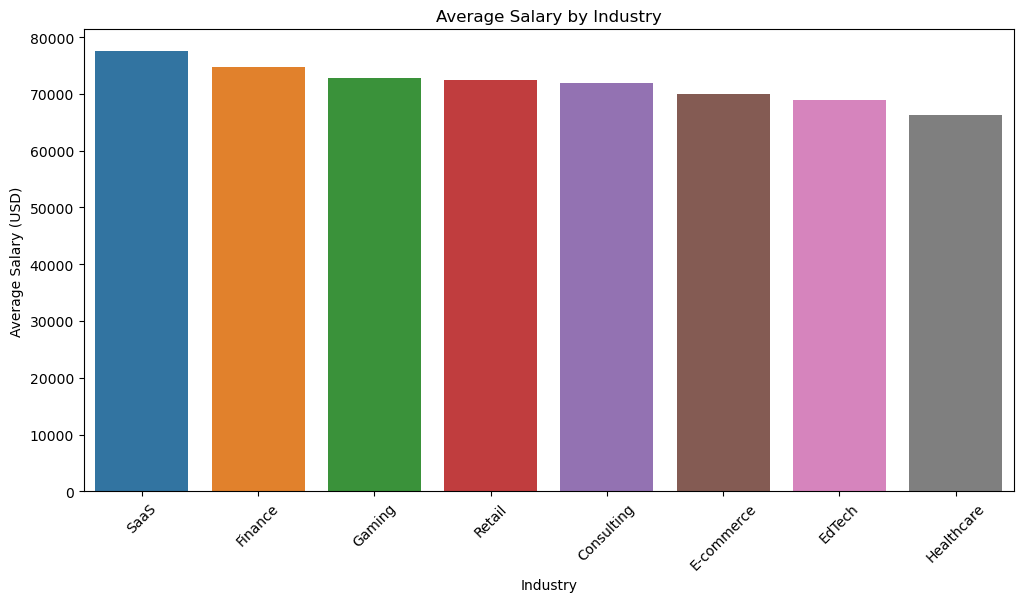

In [23]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=industry_salary.index,
    y=industry_salary.values
)

plt.title("Average Salary by Industry")

plt.xlabel("Industry")

plt.ylabel("Average Salary (USD)")

plt.xticks(rotation=45)

plt.show()

## Industry-wise Salary Insight

The analysis highlights noticeable salary variation across industries within the global data science market.

EdTech recorded the highest average salary at approximately 74,698 USD, followed closely by SaaS and Finance 
industries with average salaries above 73,000 USD.

In contrast, industries such as Retail and E-commerce showed comparatively lower salary levels near 66,000 USD.

These differences may be influenced by:
- industry profitability
- technology adoption levels
- demand for data-driven decision making
- investment in AI and analytics infrastructure

In [24]:
# calculate average salary by programming language
language_salary = df.groupby("programming_language")["salary_usd"].mean().sort_values(ascending=False)
language_salary

programming_language
Python    74578.237089
Scala     71984.699187
SQL       71920.303483
R         69772.728606
Julia     69715.776081
Name: salary_usd, dtype: float64

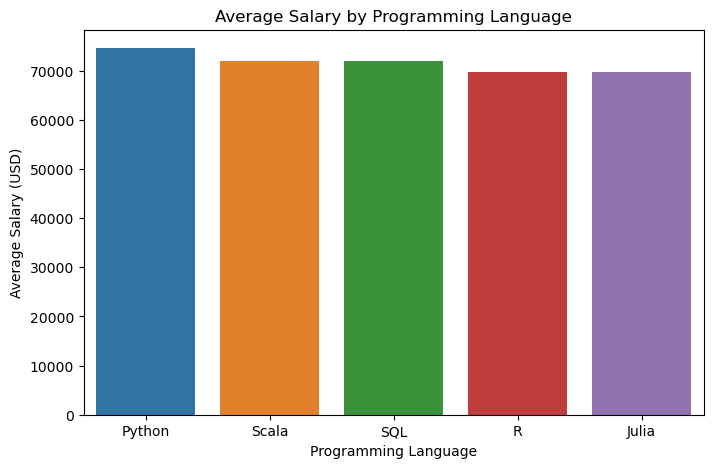

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=language_salary.index,
    y=language_salary.values
)

plt.title("Average Salary by Programming Language")

plt.xlabel("Programming Language")

plt.ylabel("Average Salary (USD)")

plt.show()

## Programming Language Salary Insight

The analysis reveals noticeable salary variation across programming languages used within the data science industry.

Python recorded the highest average salary at approximately 74,578 USD, highlighting its strong demand across data science,
machine learning, and AI-related roles.

Scala and SQL also demonstrated competitive salary levels above 71,000 USD, suggesting their importance in large-scale 
data processing and database management environments.

In comparison, R and Julia showed relatively lower average salary levels, although they continue to remain valuable 
tools within specialized analytical and research-oriented domains.

## correlation analysis

In [26]:
## correlation between numerical features
numerical_df = df[
    [
        "years_experience",
        "salary_usd",
        "work_hours_per_week",
        "satisfaction_score"
    ]
]

In [27]:
correlation_matrix = numerical_df.corr()
correlation_matrix

,years_experience,salary_usd,work_hours_per_week,satisfaction_score
years_experience,1.000000,0.381291,-0.010587,-0.009554
salary_usd,0.381291,1.000000,-0.022827,0.042064
work_hours_per_week,-0.010587,-0.022827,1.000000,0.005748
satisfaction_score,-0.009554,0.042064,0.005748,1.000000


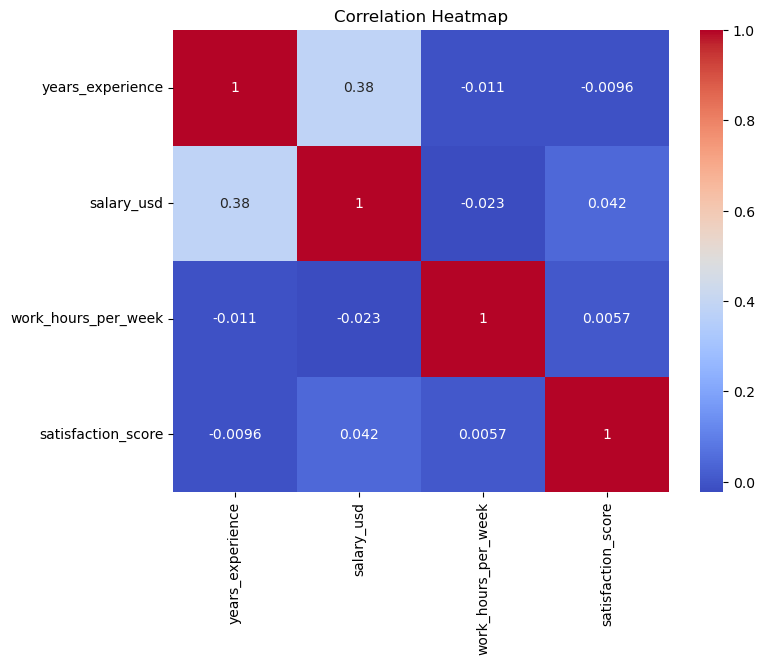

In [28]:
### correlation heatmap visualization
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()



## Correlation Analysis Insight

The correlation analysis indicates a moderate positive relationship between years of experience and salary,
with a correlation value of approximately 0.38. This suggests that employees with greater professional experience
generally tend to receive higher compensation.

In contrast, work hours per week and satisfaction score show very weak correlations with salary, indicating that salary 
levels are influenced more strongly by factors such as experience, job role, and country rather than working hours or
employee satisfaction alone.

Overall, the heatmap highlights that experience is one of the most influential numerical factors affecting salary 
within the dataset.

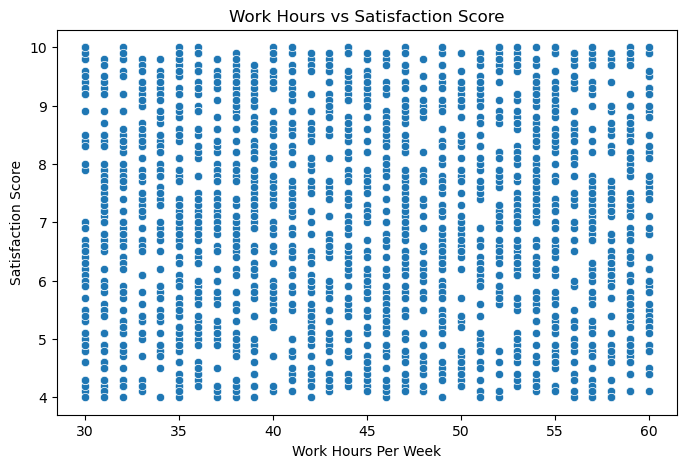

In [30]:
# work hour vs satisfaction analysis
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=df["work_hours_per_week"],
    y=df["satisfaction_score"]
)

plt.title("Work Hours vs Satisfaction Score")

plt.xlabel("Work Hours Per Week")

plt.ylabel("Satisfaction Score")

plt.show()

## Work Hours vs Satisfaction Insight

The scatterplot analysis shows no strong relationship between weekly work hours and employee satisfaction levels.

Employees working both lower and higher weekly hours reported a wide range of satisfaction scores, indicating
that work satisfaction is influenced by multiple factors beyond workload alone.

This observation suggests that aspects such as compensation, work culture, career growth opportunities, and 
workplace flexibility may play a more significant role in determining employee satisfaction within the data science 
industry.

### ADVANCED VISUALIZATION

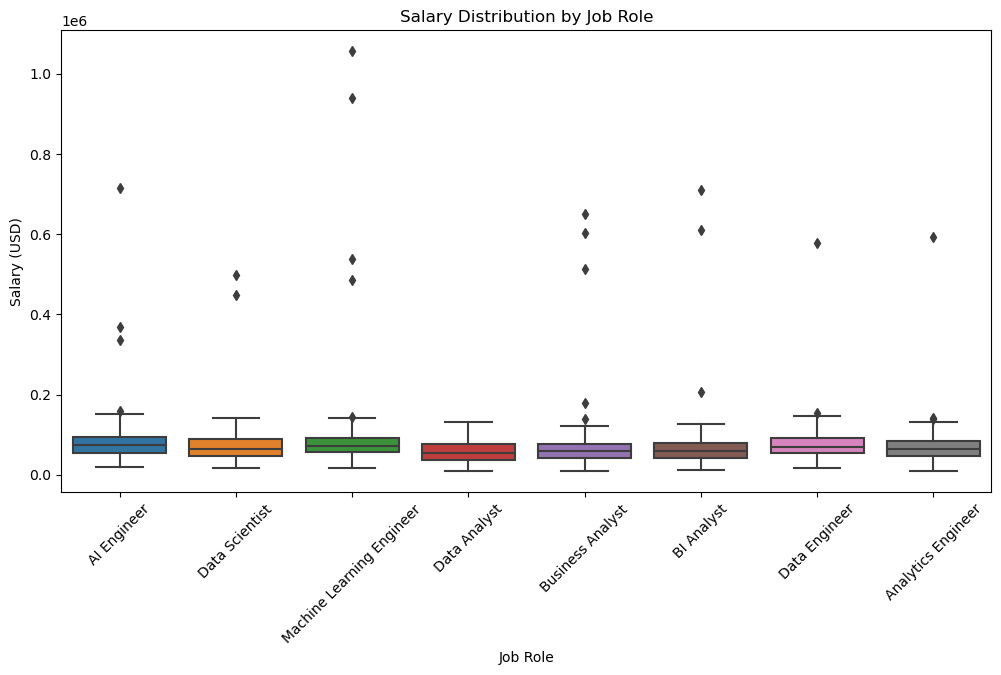

In [31]:
## salary distribution by job role
# boxplot analysis
plt.figure(figsize=(12, 6))

sns.boxplot(
    x=df["job_title"],
    y=df["salary_usd"]
)

plt.title("Salary Distribution by Job Role")

plt.xlabel("Job Role")

plt.ylabel("Salary (USD)")

plt.xticks(rotation=45)

plt.show()

## Salary Distribution by Job Role Insight

The boxplot analysis indicates that AI Engineer roles maintain the highest salary levels among all job categories,
reflecting strong industry demand for advanced artificial intelligence expertise.

Machine Learning Engineer positions show a wider salary distribution, suggesting that compensation varies significantly
based on experience level, technical specialization, and organizational requirements.

In contrast, Data Analyst roles demonstrate comparatively lower salary ranges, indicating more standardized compensation
structures and lower salary variability within entry-to-mid level analytical positions.

### feature engineering

In [32]:
## creating derived feature
# create salary category
def salary_category(salary):

    if salary < 50000:
        return "Low"

    elif salary < 80000:
        return "Medium"

    else:
        return "High"


df["salary_category"] = df["salary_usd"].apply(salary_category)

In [33]:
df[["salary_usd", "salary_category"]].head()

,salary_usd,salary_category
0,65078.0,Medium
1,65078.0,Medium
2,72818.0,Medium
3,90184.0,High
4,41244.0,Low


### Insight

The salary categorization feature successfully grouped employees into Low, Medium, and High income segments based 
on annual salary ranges.

The sample output demonstrates that employees earning around 65,000–72,000 USD fall into the Medium salary category,
while salaries above 80,000 USD are classified as High income. Lower salary ranges such as 41,244 USD were categorized
as Low income.

This feature improves salary segmentation and supports easier business interpretation, comparative analysis, and
future predictive modeling tasks.

In [34]:
# experience bucket feature
def experience_bucket(years):

    if years <= 2:
        return "Beginner"

    elif years <= 5:
        return "Intermediate"

    else:
        return "Expert"


df["experience_bucket"] = df["years_experience"].apply(experience_bucket)

In [35]:
df[
    [
        "years_experience",
        "experience_bucket"
    ]
].head()

,years_experience,experience_bucket
0,20,Expert
1,13,Expert
2,11,Expert
3,18,Expert
4,1,Beginner


### Insight

The experience bucket feature successfully categorized employees into Beginner, Intermediate, and Expert groups 
based on years of professional experience.

The sample output shows that employees with 11–20 years of experience were classified as Experts, while employees 
with very limited experience such as 1 year were categorized as Beginners.

This transformation simplifies workforce segmentation and helps improve the interpretability of salary progression, 
career growth analysis, and experience-based comparisons within the dataset.

### binary classification logic
#### High Income Flag Feature

In [38]:
## Create Binary Feature

df["high_income_flag"] = df["salary_usd"].apply(
    lambda x: 1 if x >= 80000 else 0
)

In [39]:
df[
    [
        "salary_usd",
        "high_income_flag"
    ]
].head()

,salary_usd,high_income_flag
0,65078.0,0
1,65078.0,0
2,72818.0,0
3,90184.0,1
4,41244.0,0


### Insight

The high income flag feature successfully classified employees into high-income and non-high-income categories based on an annual salary threshold of 80,000 USD.

The sample output shows that employees earning below the threshold, such as 65,078 USD and 72,818 USD, were assigned a value of 0, while employees earning above 80,000 USD, such as 90,184 USD, were assigned a value of 1.

This binary feature improves segmentation analysis and introduces a machine learning-oriented approach commonly used in classification and predictive analytics tasks.

In [40]:
### statistical analysis
from scipy.stats import ttest_ind

In [41]:
## Remote Work Salary Comparison
remote_salary = df[
    df["remote_type"] == "Remote"
]["salary_usd"]

onsite_salary = df[
    df["remote_type"] == "Onsite"
]["salary_usd"]

In [42]:
# perform T test
t_stat, p_value = ttest_ind(
    remote_salary,
    onsite_salary
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 3.3309108060813593
P-value: 0.0008896384645160598


## Remote Work Salary Statistical Insight

An independent t-test was conducted to compare salary differences between remote and onsite employees.

The analysis produced a t-statistic of approximately 3.33 and a p-value of 0.00089.

Since the p-value is significantly lower than the standard significance threshold of 0.05, the results indicate a statistically significant difference between remote and onsite employee salaries.

This suggests that remote employees in the dataset tend to earn higher salaries compared to onsite employees, potentially reflecting the growing global demand for remote data professionals and access to international job opportunities.